In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
import numpy as np
from tqdm import tqdm
from collections import Counter

In [2]:
# --- 1. Configurations ---
BASE_DIR = '/teamspace/studios/this_studio/dataset'
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.001
NUM_CLASSES = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE_PATH = 'best_lens_model.pth'

In [ ]:
# --- 2. Custom Dataset for .npy Files ---
class NumpyLensDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.filepaths = []
        self.targets = []

        # Scan directory for .npy files
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.endswith('.npy'):
                    self.filepaths.append(os.path.join(cls_dir, fname))
                    self.targets.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        label = self.targets[idx]
        
        img_np = np.load(filepath).astype(np.float32)
        
        if len(img_np.shape) == 2:
            # If it's just (H, W), add a channel dimension to make it (1, H, W)
            img_tensor = torch.from_numpy(img_np).unsqueeze(0)
        elif len(img_np.shape) == 3 and img_np.shape[-1] in [1, 3]:
            # If it's (H, W, C), permute to PyTorch's expected (C, H, W)
            img_tensor = torch.from_numpy(img_np).permute(2, 0, 1)
        else:
            # Assume it's already (C, H, W)
            img_tensor = torch.from_numpy(img_np)
            
        if img_tensor.shape[0] == 1:
            img_tensor = img_tensor.repeat(3, 1, 1)
            
        if self.transform:
            img_tensor = self.transform(img_tensor)
            
        return img_tensor, label

In [ ]:
# --- 3. Data Transforms & Augmentation ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# --- 4. Loading Data and Creating the Test Split ---
train_dir = os.path.join(BASE_DIR, 'train')
val_dir = os.path.join(BASE_DIR, 'val')

train_dataset = NumpyLensDataset(root_dir=train_dir, transform=train_transforms)
full_val_dataset = NumpyLensDataset(root_dir=val_dir, transform=eval_transforms)

val_size = len(full_val_dataset) // 2
test_size = len(full_val_dataset) - val_size
val_dataset, test_dataset = random_split(full_val_dataset, [val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes

# Dataset Statistics 
print("--- Dataset Statistics ---")
print(f"Total Classes: {class_names}")
print(f"Training Samples: {len(train_dataset)}")
print(f"Validation Samples: {len(val_dataset)}")
print(f"Testing Samples: {len(test_dataset)}")

train_counts = Counter(train_dataset.targets)
print("\nTraining Class Distribution:")
for class_idx, count in train_counts.items():
    print(f" - {class_names[class_idx]}: {count} images")

test_targets = [full_val_dataset.targets[i] for i in test_dataset.indices]
test_counts = Counter(test_targets)
print("\nTesting Class Distribution:")
for class_idx, count in test_counts.items():
    print(f" - {class_names[class_idx]}: {count} images")
print("--------------------------\n")

--- Dataset Statistics ---
Total Classes: ['no', 'sphere', 'vort']
Training Samples: 30000
Validation Samples: 3750
Testing Samples: 3750

Training Class Distribution:
 - no: 10000 images
 - sphere: 10000 images
 - vort: 10000 images

Testing Class Distribution:
 - vort: 1203 images
 - no: 1282 images
 - sphere: 1265 images
--------------------------



In [ ]:
# --- 5. Model Setup ---
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

Starting Training on cuda...


Epoch 1/30 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 1.1191 | Val Loss: 1.0982 | Val Acc: 0.3296 | LR: 0.001000
  => Val loss improved from inf to 1.0982. Saving model!


Epoch 2/30 | Train Loss: 0.9986 | Val Loss: 0.9783 | Val Acc: 0.5221 | LR: 0.001000
  => Val loss improved from 1.0982 to 0.9783. Saving model!


Epoch 3/30 | Train Loss: 0.6946 | Val Loss: 0.4780 | Val Acc: 0.8163 | LR: 0.001000
  => Val loss improved from 0.9783 to 0.4780. Saving model!


...

Epoch 27/30 | Train Loss: 0.1368 | Val Loss: 0.1548 | Val Acc: 0.9480 | LR: 0.000000
  => Val loss improved from 0.1551 to 0.1548. Saving model!


Epoch 28/30 | Train Loss: 0.1339 | Val Loss: 0.1572 | Val Acc: 0.9461 | LR: 0.000000


Epoch 29/30 | Train Loss: 0.1395 | Val Loss: 0.1618 | Val Acc: 0.9453 | LR: 0.000000


Epoch 30/30 | Train Loss: 0.1370 | Val Loss: 0.1566 | Val Acc: 0.9464 | LR: 0.000000

--- Final Evaluation on Test Set ---



Classification Report:
              precision    recall  f1-score   support

          no       0.92      1.00      0.96      1282
      sphere       0.98      0.89      0.93      1265
        vort       0.95      0.96      0.95      1203

    accuracy                           0.95      3750
   macro avg       0.95      0.95      0.95      3750
weighted avg       0.95      0.95      0.95      3750

Generating Confusion Matrix plot...


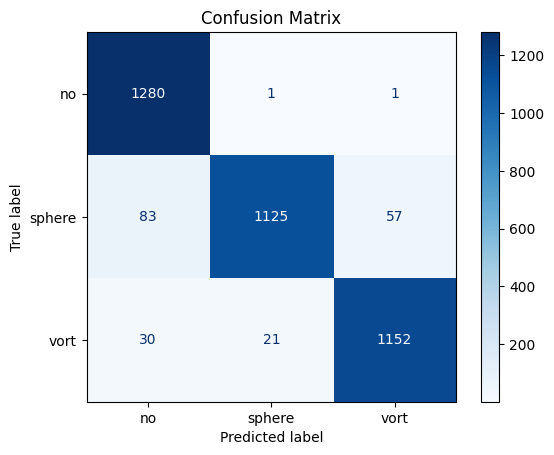

Generating ROC Curve plot...


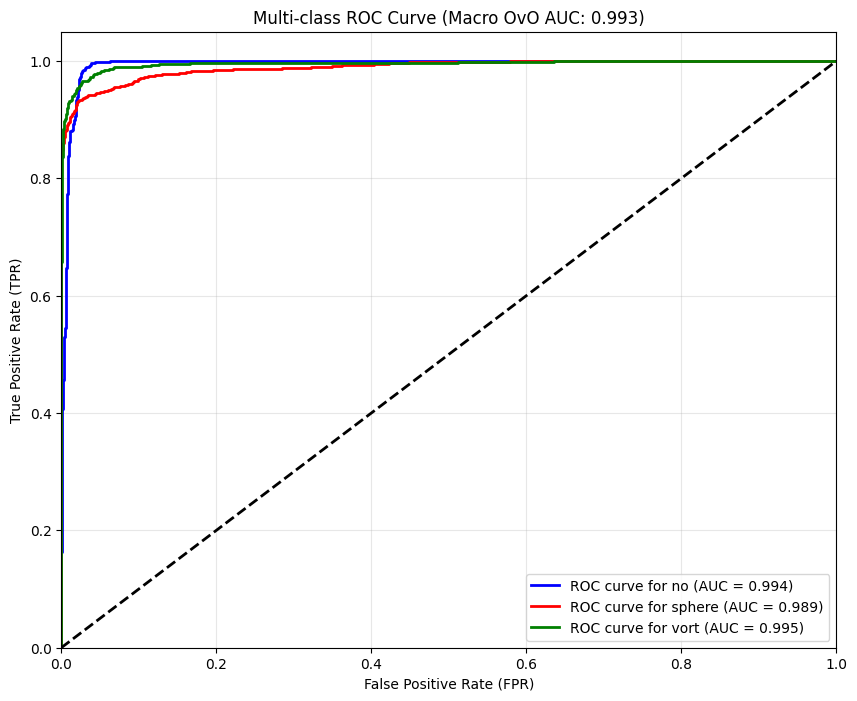

In [ ]:
# --- 6. Training Loop with tqdm & Checkpointing ---
print(f"Starting Training on {DEVICE}...")
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    for inputs, labels in train_bar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        train_bar.set_postfix(loss=(running_loss / ((train_bar.n + 1) * BATCH_SIZE)))
        
    epoch_loss = running_loss / len(train_dataset)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
    with torch.no_grad():
        for inputs, labels in val_bar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            
    val_loss = val_loss / len(val_dataset)
    val_acc = correct.double() / len(val_dataset)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")

    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        print(f"  => Val loss improved from {best_val_loss:.4f} to {val_loss:.4f}. Saving model!")
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

# Evaluation: Metrics & Confusion Matrix on TEST SET
print("\n--- Final Evaluation on Test Set ---")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

y_true = []
y_pred = []
y_scores = []

test_bar = tqdm(test_loader, desc="Evaluating", leave=False)
with torch.no_grad():
    for inputs, labels in test_bar:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Generating Confusion Matrix plot...")
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names, cmap=plt.cm.Blues)
disp.ax_.set_title("Confusion Matrix")
plt.show()

print("Generating ROC Curve plot...")
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve for {class_names[i]} (AUC = {roc_auc:.3f})')

macro_roc_auc_ovo = roc_auc_score(y_true, y_scores, multi_class="ovo", average="macro")
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'Multi-class ROC Curve (Macro OvO AUC: {macro_roc_auc_ovo:.3f})')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()